In [2]:
# Importing the packages 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importing the datasets
date = pd.read_csv('dataset/dim_date.csv')
district = pd.read_csv('dataset/dim_districts.csv')
stamps = pd.read_csv('dataset/fact_stamps.csv')
transport = pd.read_csv('dataset/fact_transport.csv')
ipass = pd.read_csv('dataset/fact_TS_iPASS.csv')

In [4]:
date.head()

,month,Mmm,quarter,fiscal_year
0,2019-04-01,Apr,Q1,2019
1,2019-05-01,May,Q1,2019
2,2019-06-01,Jun,Q1,2019
3,2019-07-01,Jul,Q2,2019
4,2019-08-01,Aug,Q2,2019


In [5]:
district.head()

,dist_code,district
0,19_1,Adilabad
1,22_2,Bhadradri Kothagudem
2,21_1,Hanumakonda
3,16_1,Hyderabad
4,20_2,Jagtial


In [6]:
stamps.head()

,dist_code,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev
0,14_1,2019-04-01,4533,59236363,0,0
1,17_3,2019-04-01,4151,41508762,0,0
2,20_3,2019-04-01,2116,23674170,0,0
3,21_5,2019-04-01,1089,15915285,0,0
4,23_1,2019-04-01,6133,82593256,0,0


In [7]:
transport.head()

,dist_code,month,fuel_type_petrol,fuel_type_diesel,fuel_type_electric,fuel_type_others,vehicleClass_MotorCycle,vehicleClass_MotorCar,vehicleClass_AutoRickshaw,vehicleClass_Agriculture,vehicleClass_others,seatCapacity_1_to_3,seatCapacity_4_to_6,seatCapacity_above_6,Brand_new_vehicles,Pre-owned_vehicles,category_Non-Transport,category_Transport
0,15_1,2019-04-01,17910,3011,76,22,15308,4429,0,4,1278,16110,4182,717,19542,1477,19856,1163
1,18_2,2019-04-01,3066,306,6,0,2995,142,49,64,128,3156,189,33,3322,56,3203,175
2,20_3,2019-04-01,1577,215,0,0,1546,79,29,21,117,1683,104,5,1751,41,1648,144
3,21_3,2019-04-01,1961,281,2,0,1939,72,72,48,113,2082,146,16,2209,35,2075,169
4,21_7,2019-04-01,1552,309,0,0,1512,76,69,109,95,1696,145,20,1820,41,1701,160


In [8]:
ipass.head()

,dist_code,month,sector,investment in cr,number_of_employees
0,14_1,01-04-2019,Engineering,2.3200,15
1,19_1,01-04-2019,Engineering,0.6250,13
2,20_3,01-04-2019,Wood and Leather,0.2000,8
3,20_3,01-04-2019,Textiles,0.2675,27
4,21_5,01-04-2019,Electrical and Electronic Products,0.1200,5


In [9]:
# Convert date columns to datetime format
date['month'] = pd.to_datetime(date['month'])
stamps['month'] = pd.to_datetime(stamps['month'])
transport['month'] = pd.to_datetime(transport['month'])
ipass['month'] = pd.to_datetime(ipass['month'])

# Merge data on common keys (dist_code and month)
df = stamps.merge(transport, on=['dist_code', 'month'], how='left')
df = df.merge(ipass, on=['dist_code', 'month'], how='left')
df = df.merge(district, on='dist_code', how='left')
df = df.merge(date, on='month', how='left')

# Display merged data
df.describe


<bound method NDFrame.describe of      dist_code      month  documents_registered_cnt  documents_registered_rev  \
0         14_1 2019-04-01                      4533                  59236363   
1         17_3 2019-04-01                      4151                  41508762   
2         20_3 2019-04-01                      2116                  23674170   
3         21_5 2019-04-01                      1089                  15915285   
4         23_1 2019-04-01                      6133                  82593256   
...        ...        ...                       ...                       ...   
1863      20_4 2023-03-01                      1510                  54036552   
1864      14_5 2023-03-01                       980                  23898383   
1865      21_1 2023-03-01                      4321                 279791569   
1866      22_2 2023-03-01                      1255                  18695648   
1867      23_1 2023-03-01                      5806                 1320221

In [10]:
df=df

In [11]:
df.describe()

,month,documents_registered_cnt,documents_registered_rev,estamps_challans_cnt,estamps_challans_rev,fuel_type_petrol,fuel_type_diesel,fuel_type_electric,fuel_type_others,vehicleClass_MotorCycle,...,seatCapacity_1_to_3,seatCapacity_4_to_6,seatCapacity_above_6,Brand_new_vehicles,Pre-owned_vehicles,category_Non-Transport,category_Transport,investment in cr,number_of_employees,fiscal_year
count,1868,1868.000000,1.868000e+03,1868.000000,1.868000e+03,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,...,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,1719.000000,475.000000,475.000000,1868.000000
mean,2021-03-25 01:34:49.079229184,3967.038009,2.727791e+08,2622.345824,2.168139e+08,4399.714369,762.168703,91.874346,67.362420,3799.760908,...,4279.780686,916.635253,122.771960,4947.286795,373.955207,4823.939500,497.302501,17.227399,189.265263,2020.464133
min,2019-04-01 00:00:00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.000000,0.000000,0.000000,6.000000,0.000000,6.000000,0.000000,0.000000,0.000000,2019.000000
25%,2020-03-01 00:00:00,1153.000000,2.065573e+07,0.000000,0.000000e+00,1489.500000,288.000000,2.000000,2.000000,1381.000000,...,1623.500000,177.500000,22.000000,1782.500000,64.000000,1666.500000,170.500000,0.240000,8.000000,2019.000000
50%,2021-02-01 00:00:00,2194.500000,4.107807e+07,1009.000000,2.206125e+07,2313.000000,490.000000,10.000000,9.000000,2092.000000,...,2479.000000,307.000000,41.000000,2724.000000,113.000000,2535.000000,288.000000,0.750100,15.000000,2020.000000
75%,2022-03-01 00:00:00,4586.750000,1.188569e+08,2991.000000,7.847812e+07,4078.500000,862.000000,42.500000,50.000000,3588.500000,...,4160.000000,673.000000,88.000000,4778.000000,200.000000,4538.000000,534.500000,3.017500,35.500000,2021.000000
max,2023-03-01 00:00:00,31310.000000,4.073496e+09,30526.000000,4.294273e+09,39689.000000,5270.000000,2782.000000,2326.000000,35420.000000,...,36694.000000,7918.000000,1337.000000,42073.000000,4450.000000,42074.000000,4239.000000,1553.000000,57000.000000,2022.000000
std,NaN,5142.712201,6.479491e+08,4894.196004,6.374382e+08,5588.609831,774.912413,286.222020,192.593254,4582.646685,...,4928.943263,1504.957809,216.505508,5907.807611,696.883565,6052.340835,619.458487,113.369665,2636.347035,1.123970


               district  documents_registered_rev
0              Adilabad                 204237091
1  Bhadradri Kothagudem                 129781111
2           Hanumakonda                1422527983
3             Hyderabad                7051327326
4               Jagtial                 106454913


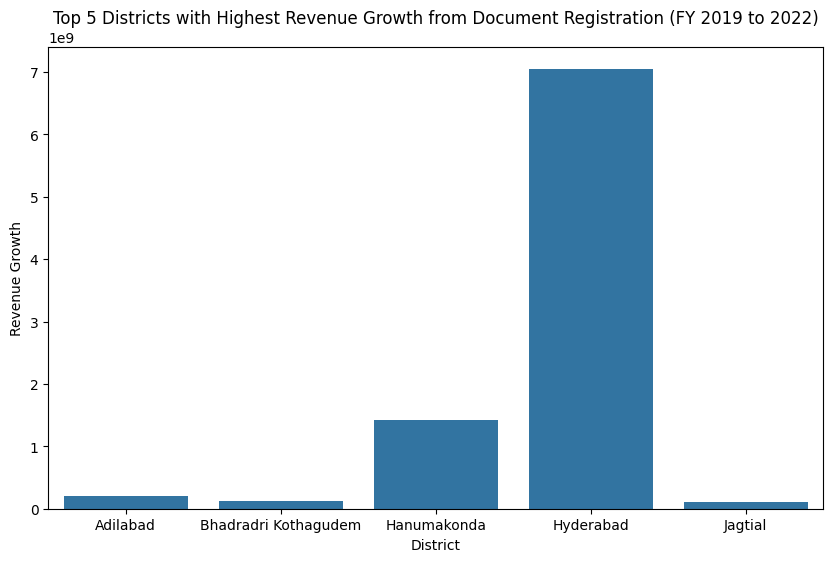

In [12]:
# Filter data for FY 2019 and FY 2022
fy_2019 = df[df['fiscal_year'] == 2019]
fy_2022 = df[df['fiscal_year'] == 2022]

# Calculate revenue growth between FY 2019 and 2022
revenue_2019 = fy_2019.groupby('district')['documents_registered_rev'].sum()
revenue_2022 = fy_2022.groupby('district')['documents_registered_rev'].sum()
revenue_growth = (revenue_2022 - revenue_2019).reset_index()

# Top 5 districts with highest revenue growth
top_5_districts = revenue_growth.head(5)
print(top_5_districts)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='district', y='documents_registered_rev', data=top_5_districts)
plt.title('Top 5 Districts with Highest Revenue Growth from Document Registration (FY 2019 to 2022)')
plt.xlabel('District')
plt.ylabel('Revenue Growth')
plt.show()


               district  documents_registered_rev  estamps_challans_rev  \
15   Medchal_Malkajgiri               41174830970           41622734748   
31  Yadadri Bhuvanagiri                3408179667            3768713643   
24           Rangareddy               61447337874           61643708858   
3             Hyderabad               15350733604           15510182221   
26             Siddipet                1348900558            1433058925   

    revenue_diff  
15     447903778  
31     360533976  
24     196370984  
3      159448617  
26      84158367  


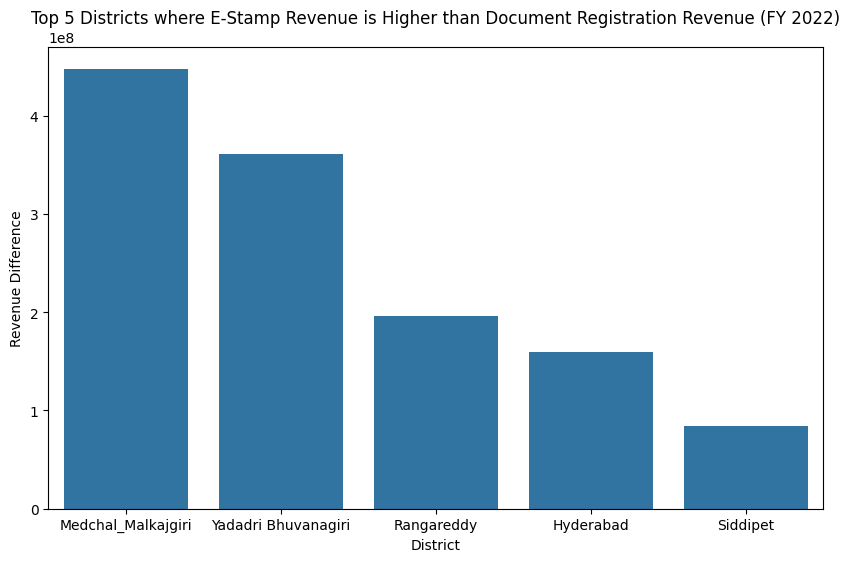

In [23]:
# Calculate total revenue for documents and e-stamps in FY 2022
fy_2022_revenue = fy_2022.groupby('district').agg({'documents_registered_rev': 'sum', 'estamps_challans_rev': 'sum'}).reset_index()

# Find top 5 districts where e-stamps revenue is significantly more
fy_2022_revenue['revenue_diff'] = fy_2022_revenue['estamps_challans_rev'] - fy_2022_revenue['documents_registered_rev']
top_5_estamps = fy_2022_revenue.sort_values(by='revenue_diff', ascending=False).head(5)
print(top_5_estamps)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='district', y='revenue_diff', data=top_5_estamps)
plt.title('Top 5 Districts where E-Stamp Revenue is Higher than Document Registration Revenue (FY 2022)')
plt.xlabel('District')
plt.ylabel('Revenue Difference')
plt.show()


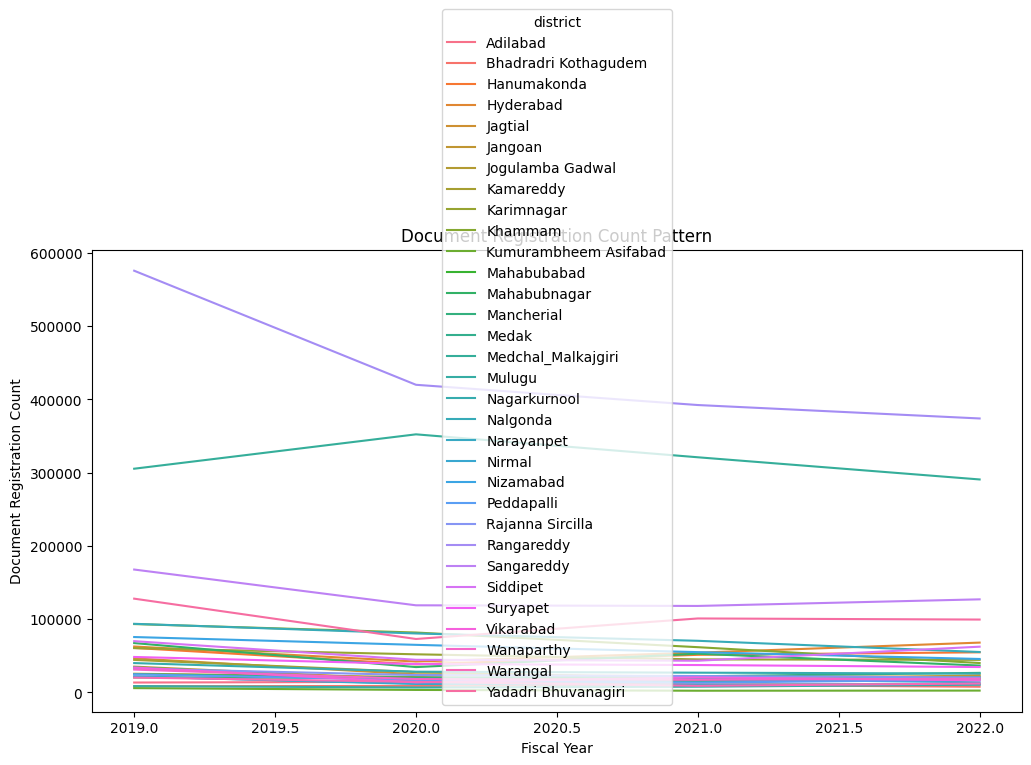

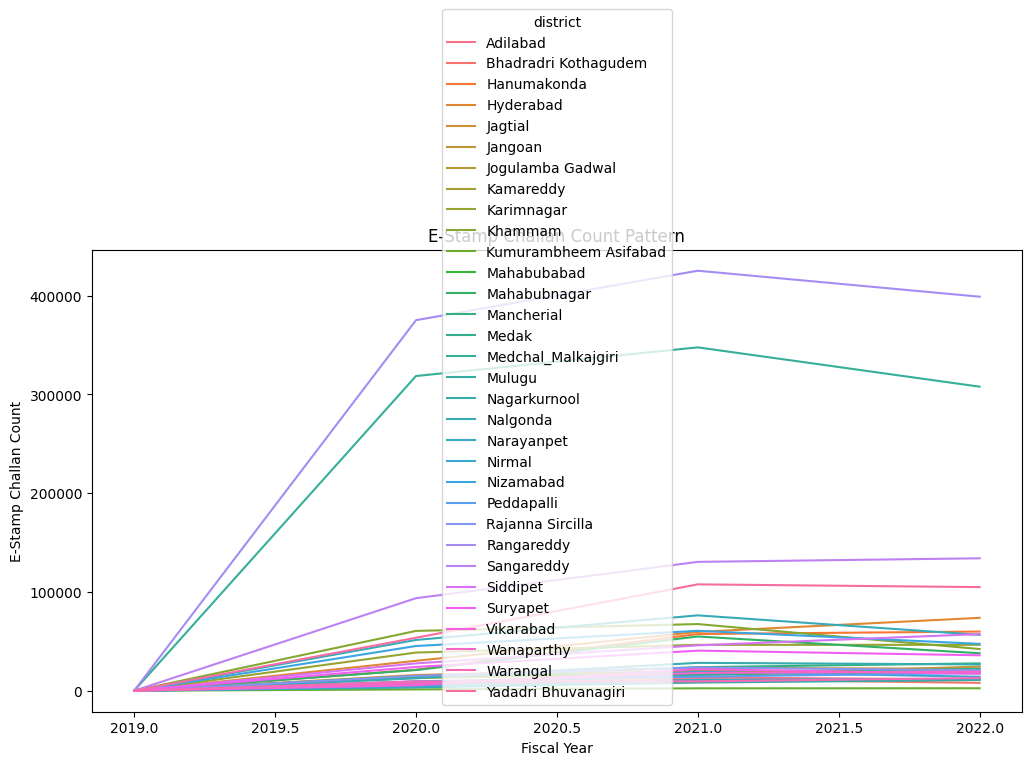

In [25]:
# Analyze pattern changes since e-Stamp implementation
pattern_change = df.groupby(['fiscal_year', 'district']).agg({
    'documents_registered_cnt': 'sum',
    'estamps_challans_cnt': 'sum'
}).reset_index()

# Visualize the patterns
plt.figure(figsize=(12, 6))
sns.lineplot(data=pattern_change, x='fiscal_year', y='documents_registered_cnt', hue='district')
plt.title('Document Registration Count Pattern')
plt.xlabel('Fiscal Year')
plt.ylabel('Document Registration Count')
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=pattern_change, x='fiscal_year', y='estamps_challans_cnt', hue='district')
plt.title('E-Stamp Challan Count Pattern')
plt.xlabel('Fiscal Year')
plt.ylabel('E-Stamp Challan Count')
plt.show()
